# Müşteri Kaybı (Churn) Analizi

Bu çalışmada bir telekom şirketinin müşteri verisiyle şu iki soruya cevap aramaya çalıştım:

1. Hangi müşteriler şirketi bırakıyor (churn)?
2. Elimizde bir kampanya bütçesi olsa, teklifi **kime** yapmak daha kârlı olur?

Veri: IBM Telco Customer Churn (7.043 müşteri).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, precision_score, accuracy_score, roc_auc_score

## 1. Veriyi yükleme

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Her satır bir müşteri. Müşterinin aldığı hizmetler, sözleşme tipi, ödeme yöntemi, aylık ücreti ve
şirketten ayrılıp ayrılmadığı (`Churn`) bilgisi var.

## 2. Veriyi temizleme

In [3]:
# TotalCharges should be a number but it was read as text
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

# Look at the rows with missing values
df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


`TotalCharges` (toplam ödeme) sütununda 11 boş değer var. Bu müşterilerin hepsinin `tenure` (müşteri süresi)
değeri 0, yani yeni gelmişler ve henüz fatura ödememişler. Bu yüzden bu satırları silmek yerine boş değerleri 0 yaptım.

In [4]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Churn: Yes -> 1, No -> 0
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("Churn rate:", round(df["Churn"].mean() * 100, 1), "%")

Churn rate: 26.5 %


Müşterilerin **%26.5'i** şirketten ayrılmış. Yani yaklaşık her 4 müşteriden 1'i.

## 3. Hangi müşteriler daha çok ayrılıyor?

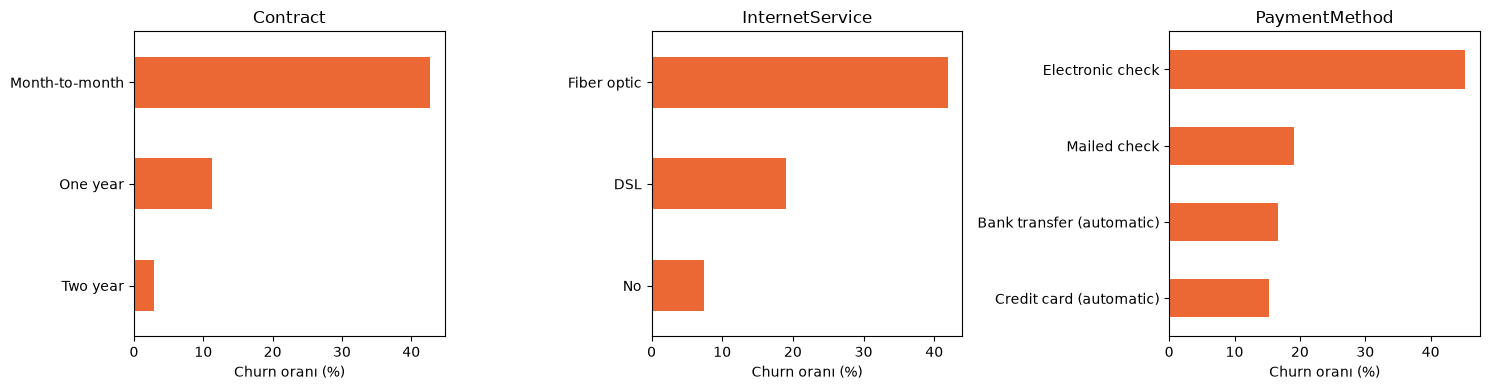

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64 

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64 

PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64 



In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    rate = df.groupby(col)["Churn"].mean().sort_values() * 100
    rate.plot(kind="barh", ax=ax, color="#eb6834")
    ax.set_title(col)
    ax.set_xlabel("Churn oranı (%)")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/churn_oranlari.png", dpi=120, bbox_inches="tight")
plt.show()

for col in ["Contract", "InternetService", "PaymentMethod"]:
    print((df.groupby(col)["Churn"].mean() * 100).round(1), "\n")

En dikkat çekici sonuçlar:

- **Sözleşme tipi:** Aylık sözleşmesi olanların %42.7'si ayrılmış, 2 yıllık sözleşmesi olanlarda bu oran sadece %2.8.
- **İnternet hizmeti:** Fiber internet kullananların %41.9'u ayrılmış, DSL'de bu oran %19.0.
- **Ödeme yöntemi:** Electronic check ile ödeyenlerde churn oranı %45.3. Otomatik ödeme (banka / kredi kartı) kullananlarda %15-17 civarında.

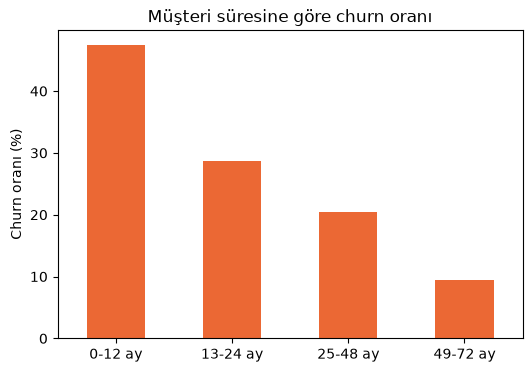

tenure_group
0-12 ay     47.4
13-24 ay    28.7
25-48 ay    20.4
49-72 ay     9.5
Name: Churn, dtype: float64


In [6]:
# Group customers by how many months they have been with the company
df["tenure_group"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12 ay", "13-24 ay", "25-48 ay", "49-72 ay"])
rate = df.groupby("tenure_group", observed=True)["Churn"].mean() * 100

rate.plot(kind="bar", color="#eb6834", figsize=(6, 4))
plt.title("Müşteri süresine göre churn oranı")
plt.ylabel("Churn oranı (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.savefig("../outputs/sureye_gore_churn.png", dpi=120, bbox_inches="tight")
plt.show()

print(rate.round(1))

Yeni müşteriler çok daha fazla ayrılıyor: ilk 12 aydaki müşterilerin %47.4'ü ayrılmış, 4 yıldan uzun süredir
müşteri olanlarda bu oran %9.5.

## 4. Model

Müşterinin ayrılıp ayrılmayacağını tahmin etmek için **Logistic Regression** kullandım. Bu model her müşteri için
0 ile 1 arasında bir "ayrılma olasılığı" veriyor.

Adımlar:
- Metin sütunlarını (ör. sözleşme tipi) `get_dummies` ile 0/1 sütunlarına çevirdim.
- `TotalCharges`'ı modele koymadım, çünkü aşağı yukarı müşteri süresi × aylık ücrete eşit, yani yeni bir bilgi taşımıyor.
- Veriyi %80 eğitim, %20 test olarak ayırdım. Model eğitim verisiyle öğreniyor, test verisiyle kontrol ediyorum.
- `tenure` ve `MonthlyCharges` farklı ölçeklerde olduğu için (aylar ve dolar) `StandardScaler` ile aynı ölçeğe getirdim.

In [7]:
# Remove columns we don't use in the model
X = df.drop(columns=["customerID", "Churn", "TotalCharges", "tenure_group"])
y = df["Churn"]

# Turn text columns into 0/1 columns
X = pd.get_dummies(X, drop_first=True, dtype=int)
print(X.shape)

# 80% train, 20% test. stratify keeps the churn rate the same in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Put tenure and MonthlyCharges on the same scale
scaler = StandardScaler()
num_cols = ["tenure", "MonthlyCharges"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

(7043, 29)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

## 5. Model ne kadar iyi?

In [8]:
proba = model.predict_proba(X_test)[:, 1]   # churn probability for each test customer
pred = (proba >= 0.5).astype(int)           # 1 if probability is 50% or more

print(confusion_matrix(y_test, pred))
print("Accuracy :", round(accuracy_score(y_test, pred), 3))
print("Recall   :", round(recall_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))

[[918 117]
 [170 204]]
Accuracy : 0.796
Recall   : 0.545
Precision: 0.636
ROC-AUC  : 0.839


Test setinde 1.409 müşteri var, bunların 374'ü gerçekten ayrılmış.

- **Accuracy %79.6** iyi görünüyor ama yanıltıcı olabilir: herkese "kalır" diyen bir model bile %73.5 doğru tahmin eder.
  Bu yüzden diğer metriklere de baktım.
- **Recall %54.5:** Gerçekten ayrılan 374 müşterinin 204'ünü yakaladık, 170'ini kaçırdık.
- **Precision %63.6:** "Ayrılacak" dediğimiz 321 müşterinin 204'ü gerçekten ayrılmış.
- **ROC-AUC 0.839:** Modelin ayrılacak müşterileri kalacaklardan ne kadar iyi ayırdığını gösteriyor (0.5 = rastgele, 1 = mükemmel).

## 6. Hangi özellikler riski artırıyor?

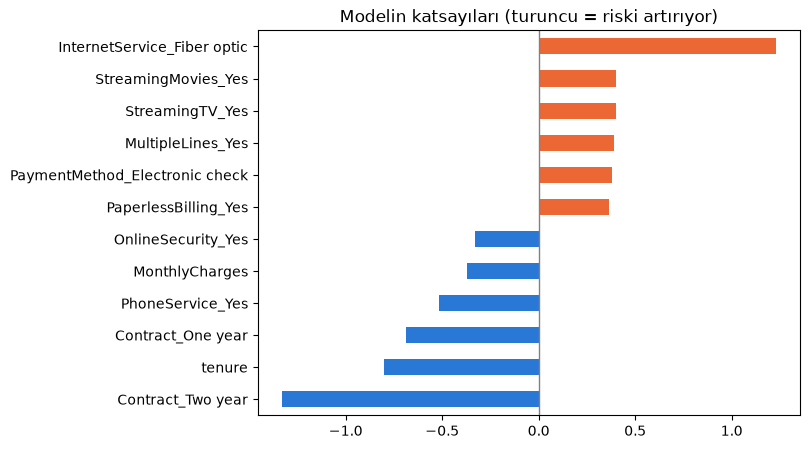

Contract_Two year                -1.33
tenure                           -0.80
Contract_One year                -0.69
PhoneService_Yes                 -0.51
MonthlyCharges                   -0.37
OnlineSecurity_Yes               -0.33
PaperlessBilling_Yes              0.36
PaymentMethod_Electronic check    0.38
MultipleLines_Yes                 0.39
StreamingTV_Yes                   0.40
StreamingMovies_Yes               0.40
InternetService_Fiber optic       1.23
dtype: float64

In [9]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
top = pd.concat([coefs.head(6), coefs.tail(6)])

colors = ["#2a78d6" if c < 0 else "#eb6834" for c in top]
top.plot(kind="barh", color=colors, figsize=(7, 5))
plt.title("Modelin katsayıları (turuncu = riski artırıyor)")
plt.axvline(0, color="gray", linewidth=1)
plt.savefig("../outputs/model_katsayilari.png", dpi=120, bbox_inches="tight")
plt.show()

top.round(2)

Turuncu çubuklar ayrılma ihtimalini artıran, mavi çubuklar azaltan özellikler.

- **Riski azaltanlar:** 1 veya 2 yıllık sözleşme, uzun müşteri süresi, online güvenlik hizmeti.
- **Riski artıranlar:** fiber internet, electronic check ile ödeme, kağıtsız fatura, streaming hizmetleri.

Bu sonuçlar 3. bölümdeki grafiklerle de uyumlu.

**Dikkat:** Aylık ücretin katsayısı negatif çıktı, yani "pahalı paket riski azaltıyor" gibi görünüyor. Grafiklerde durum tam tersiydi.
Bunun sebebi büyük ihtimalle pahalı hizmetlerin (fiber, streaming) zaten ayrı sütunlarda olması. Sütunlar birbiriyle
ilişkili olduğunda katsayıları tek tek yorumlamak zorlaşıyor.

## 7. Kime kampanya teklifi yapmalı?

Ayrılacağını düşündüğümüz müşterilere bir kampanya teklifi (indirim gibi) yaptığımızı düşünelim. Bunun için iki varsayım yaptım
(gerçek şirket verisi değil, benim seçtiğim örnek değerler):

- Teklif yapılan her müşterinin şirkete maliyeti **$50**
- Ayrılacak bir müşteriye teklif yapılırsa **%30** ihtimalle kalıyor

Her müşteri için **beklenen kayıp = ayrılma olasılığı × yıllık gelir** hesapladım (yıllık gelir = aylık ücret × 12).
Beklenen kaybın %30'u $50'dan büyükse, yani teklif masrafını karşılıyorsa, o müşteriye teklif yapıyorum.

Bu yöntemi 3 basit stratejiyle karşılaştırdım. Test setinde kimin gerçekten ayrıldığını bildiğimiz için her stratejinin
ne kadar kazandıracağını hesaplayabiliyoruz.

In [10]:
COST = 50          # $ per customer who gets an offer
SAVE_RATE = 0.30   # share of churning customers we can keep with the offer

test = df.loc[X_test.index, ["customerID", "MonthlyCharges", "Churn"]].copy()
test["churn_probability"] = proba
test["yearly_revenue"] = test["MonthlyCharges"] * 12
test["expected_loss"] = test["churn_probability"] * test["yearly_revenue"]
test["offer"] = test["expected_loss"] * SAVE_RATE > COST

def campaign_value(offer):
    # Money we save from real churners who got the offer, minus the campaign cost
    saved = (test["yearly_revenue"] * test["Churn"] * SAVE_RATE)[offer].sum()
    cost = offer.sum() * COST
    return pd.Series({"teklif_sayisi": offer.sum(),
                      "yakalanan_churn": (offer & (test["Churn"] == 1)).sum(),
                      "maliyet": cost,
                      "kurtarilan_gelir": round(saved),
                      "net_kazanc": round(saved - cost)})

results = pd.DataFrame({
    "Kimseye teklif yok": campaign_value(test["offer"] & False),
    "Herkese teklif": campaign_value(test["offer"] | True),
    "Olasılık >= %50": campaign_value(test["churn_probability"] >= 0.5),
    "Beklenen kayıp hesabı": campaign_value(test["offer"]),
}).T
results

,teklif_sayisi,yakalanan_churn,maliyet,kurtarilan_gelir,net_kazanc
Kimseye teklif yok,0,0,0,0,0
Herkese teklif,1409,374,70450,97974,27524
Olasılık >= %50,321,204,16050,58951,42901
Beklenen kayıp hesabı,622,294,31100,83872,52772


- **Herkese teklif** yapmak $70,450'ye mal oluyor, net kazanç $27,524.
- Sadece ayrılma olasılığı **%50'nin üstünde** olanlara teklif yapmak net $42,901 kazandırıyor.
- **Beklenen kayıp hesabı** en iyi sonucu veriyor: 622 müşteriye teklif, net **$52,772**. Bu, herkese teklif yapmanın
  yaklaşık 2 katı.

Beklenen kayıp yönteminin daha iyi olmasının sebebi, sadece olasılığa değil müşterinin ne kadar ödediğine de bakması.
Az ödeyen bir müşteriyi kaybetmek, çok ödeyen bir müşteriyi kaybetmek kadar pahalı değil.

## 8. Müşteri listesi (Power BI için)

In [11]:
# Add a few customer details so the list can be used alone in Power BI
details = df.loc[X_test.index, ["Contract", "InternetService", "PaymentMethod", "tenure"]]
test = test.join(details)

customer_list = (test[test["offer"]]
                 .sort_values("expected_loss", ascending=False)
                 [["customerID", "churn_probability", "yearly_revenue", "expected_loss",
                   "Contract", "InternetService", "PaymentMethod", "tenure"]]
                 .round(2))
customer_list.to_csv("../outputs/teklif_listesi.csv", index=False)
print(len(customer_list), "müşteri kaydedildi")
customer_list.head(10)

622 müşteri kaydedildi


,customerID,churn_probability,yearly_revenue,expected_loss,Contract,InternetService,PaymentMethod,tenure
6894,1400-MMYXY,0.84,1270.8,1070.69,Month-to-month,Fiber optic,Electronic check,3
6365,8884-ADFVN,0.84,1223.4,1029.45,Month-to-month,Fiber optic,Electronic check,7
3956,4587-VVTOX,0.81,1263.6,1017.94,Month-to-month,Fiber optic,Electronic check,6
2797,6023-YEBUP,0.84,1211.4,1016.57,Month-to-month,Fiber optic,Electronic check,3
2631,6861-XWTWQ,0.85,1191.0,1007.45,Month-to-month,Fiber optic,Electronic check,7
3380,5178-LMXOP,0.87,1141.2,991.37,Month-to-month,Fiber optic,Electronic check,1
1568,3292-PBZEJ,0.74,1336.8,990.52,Month-to-month,Fiber optic,Electronic check,11
2294,2027-FECZV,0.77,1280.4,987.03,Month-to-month,Fiber optic,Electronic check,12
2448,9221-OTIVJ,0.78,1258.2,986.01,Month-to-month,Fiber optic,Electronic check,14
6866,0295-PPHDO,0.85,1145.4,972.20,Month-to-month,Fiber optic,Electronic check,1


Teklif yapılması önerilen 622 müşteriyi beklenen kayba göre sıralayıp `outputs/teklif_listesi.csv` dosyasına kaydettim.
Listeye sözleşme tipi, internet hizmeti, ödeme yöntemi ve müşteri süresi bilgilerini de ekledim; böylece dosyayı
tek başına Power BI'a yükleyip görselleştirebiliyorum.

## Sonuç

- Müşterilerin %26.5'i ayrılmış. En çok ayrılanlar aylık sözleşmeli, yeni, fiber internet kullanan ve electronic check ile ödeyen müşteriler.
- Logistic Regression modeli test setinde 0.839 ROC-AUC verdi; ayrılan müşterilerin %54.5'ini yakaladı.
- Teklifi sadece olasılığa göre değil, **beklenen kayba** göre vermek bu varsayımlarla daha kârlı çıktı.

## Eksikler / geliştirilebilecekler

- $50 maliyet ve %30 kurtarma oranı benim varsayımlarım. Gerçek değerler farklıysa sonuçlar değişir.
- Sadece bir model denedim. Başka modeller (ör. karar ağacı, random forest) denenebilir.
- Model ayrılan müşterilerin yaklaşık yarısını kaçırıyor.
- Veri tek bir zamana ait; müşterinin *ne zaman* ayrılacağını tahmin etmiyor.